# Faithfulness benchmark — shapiq.vision vs Captum KernelSHAP

Benchmarks the `shapiq.vision` pipeline (`ImageImputer` + ProxySHAP) against Captum KernelSHAP
on insertion/deletion faithfulness (AID, higher = better).

**Setup:** 200 ImageNet validation images × {ResNet-18, ViT-B/16} × {grid n=100, superpixels n=40},
both methods per cell (1,600 cells). Both arms use the same SLIC segments, the same mean-color
baseline, the same explained class (model's top-1) and the same evaluation budget
(`max(200, 8·n_seg)`), so that the AID gap isolates the estimator (ProxySHAP vs KernelSHAP).

**Result:** shapiq.vision performs better against our faithfulness metric in all 4 model × config
conditions

**Sections:**
1. **Experiment** — the full sweep. Skipped by default (`RUN_EXPERIMENT = False`); the precomputed
   results file is used instead. Set the flag to `True` to recompute.
2. **Results & figures** — loads `aid_sweep_results.pkl` and renders the figures and summary table.
   CPU, runs in seconds.

**Files needed to run this notebook:** `aid_sweep_results.pkl` (previously obtained results pickle, required for section 2, unless the full experiment is rerun in Section 1), `run_manifest.json` (image list required to rerun the experiment).


## Section 1 — Experiment

This section contains the full run of the experiment. All cells in this section are skipped unless `RUN_EXPERIMENT = True` in the next cell.

- **Environment:** installs the pinned commits below. The pins should not be advanced as a newer
  `vision_main` changed the `prepare()` signature
  - frontend `BarbaraBugala/XAI-Vision` @ `73ce3922f415143b305743c9730b01eeac50b6f4`
  - backend fork `S2k-1/shapiq`, branch `vision_main` @ `e7369997ee4225c460b11aa43637de77cc9436bd`
- **Imports from the frontend repo:** model loading/prediction (`run_prediction`), SLIC
  segmentation (`get_segmentation`), the insertion/deletion metric (`run_faithfulness`) and the
  class-forcing adapter (`shapiq_compat.ForcedClassCNNArchitecture`)
- **Images:** `benjamin-paine/imagenet-1k-256x256` (validation): the 200 images are selected by
  `dataset_index` from `run_manifest.json`. Image selection and SLIC segmentation are deterministic.
- **Resumable:** results are written to `aid_sweep_results.pkl` after every cell, so an interrupted run
  resumes where it stopped. If the completed results file is already present, nothing is recomputed.
- **Runtime:** A full run should run on GPU. `PILOT = True` restricts the sweep to the
  first 10 images for a quick end-to-end run.


In [17]:
import os

RUN_EXPERIMENT = False   # True: run the full experimental set up below. False: skip to Section 2 (precomputed results).
PILOT          = True    # True: first PILOT_N images only. False: full 200-image sweep.
PILOT_N        = 10

ROOT          = os.getcwd()
STORE_PATH    = os.path.join(ROOT, "aid_sweep_results.pkl")
MANIFEST_PATH = os.path.join(ROOT, "run_manifest.json")


In [2]:
if RUN_EXPERIMENT:
    import sys, subprocess

    XAI_COMMIT    = "73ce3922f415143b305743c9730b01eeac50b6f4"
    SHAPIQ_COMMIT = "e7369997ee4225c460b11aa43637de77cc9436bd"

    if not os.path.isdir("XAI-Vision"):
        subprocess.run(["git", "clone", "https://github.com/BarbaraBugala/XAI-Vision.git"], check=True)
    REPO_DIR = os.path.abspath("XAI-Vision")
    subprocess.run(["git", "fetch", "origin"], cwd=REPO_DIR, check=True)
    subprocess.run(["git", "checkout", XAI_COMMIT], cwd=REPO_DIR, check=True)

    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet",
                    "captum", "scikit-image", "datasets", "transformers", "xgboost"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "-q", "shapiq"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet",
                    f"git+https://github.com/S2k-1/shapiq.git@{SHAPIQ_COMMIT}"], check=True)


In [15]:
if RUN_EXPERIMENT:
    import sys
    for sub in ["xai_methods", "models", "params", "plots"]:
        init = os.path.join(REPO_DIR, "src", sub, "__init__.py")
        if not os.path.exists(init):
            open(init, "w").close()
    os.chdir(REPO_DIR)
    sys.path.insert(0, os.path.join(REPO_DIR, "src"))
    sys.path.insert(0, os.path.join(REPO_DIR, "explanations"))
    for name in list(sys.modules):
        if name in ("framework", "faithfulness") or name.startswith(
            ("xai_methods", "params", "plots", "models")):
            del sys.modules[name]

    import numpy as np, pickle, time, traceback, json
    from datetime import datetime, timedelta
    import torch
    import torch.nn as nn
    import torchvision.transforms as T

    from faithfulness import run_faithfulness
    from models.model_prediction import run_prediction
    from models.registry import get_model_config
    from params.segmentation_registry import get_segmentation
    from params.baselines import get_baseline
    from xai_methods.shapiq_compat import ForcedClassCNNArchitecture

    from shapiq.approximator import ProxySHAP
    from shapiq.vision import MeanColorMasking
    from shapiq.vision.imputer import ImageImputer
    from shapiq.vision.players import CustomPlayerStrategy
    from captum.attr import KernelShap

    print(torch.cuda.is_available())


In [16]:
if RUN_EXPERIMENT:
    from datasets import load_dataset
    from PIL import Image

    with open(MANIFEST_PATH) as f:
        META = json.load(f)
    ds = load_dataset(META["dataset"], split=META["split"])
    os.makedirs("data", exist_ok=True)

    IMAGE_SPECS = {}
    for entry in META["images"]:
        fname, di = entry["file"], entry["dataset_index"]
        if not os.path.exists(os.path.join("data", fname)):
            img = ds[di]["image"]
            if not isinstance(img, Image.Image):
                img = Image.fromarray(np.array(img))
            img.convert("RGB").save(os.path.join("data", fname))
        IMAGE_SPECS[fname] = di
    print(len(IMAGE_SPECS), "images")


In [5]:
if RUN_EXPERIMENT:
    MODELS       = ["resnet18", "vitb16"]
    SEG_CONFIGS  = [("grid", 100), ("superpixels", 40)]
    METHODS      = ["kernel_shap", "shapiq_vision"]
    MASKING      = "average"
    MAX_ORDER    = 1

    def budget_for(n_seg):
        return max(200, 8 * n_seg)

    image_list = list(IMAGE_SPECS)[:PILOT_N] if PILOT else list(IMAGE_SPECS)
    print(f"{'PILOT' if PILOT else 'FULL'}: {len(image_list)} images x {len(MODELS)} models "
          f"x {len(METHODS)} methods x {len(SEG_CONFIGS)} configs")


In [6]:
if RUN_EXPERIMENT:
    class NormalizedModel(nn.Module):
        """Wraps a model so it accepts [0,1] images"""
        def __init__(self, model, mean, std):
            super().__init__()
            self.norm = T.Normalize(mean=mean, std=std)
            self.model = model
        def forward(self, x):
            return self.model(self.norm(x))

    def _mean_std(model_name):
        tr = get_model_config(model_name)["transform"]
        mean = tr.mean if hasattr(tr, "mean") else [0.485, 0.456, 0.406]
        std  = tr.std  if hasattr(tr, "std")  else [0.229, 0.224, 0.225]
        return list(mean), list(std)

    def _segments(segmentation, n_seg, input_tensor, device):
        """Both arms of experiment use same segmentation"""
        seg_t = get_segmentation(method=segmentation, image=input_tensor,
                                 config={"n_segments": n_seg, "compactness": 10, "sigma": 1}).to(device)
        return seg_t

    def run_kernel_shap(image_path, model_name, segmentation, n_seg, class_idx, budget):
        """Captum KernelSHAP average baseline, logit target, shared segments"""
        pred = run_prediction(image_path, model_name=model_name)
        model, input_tensor, device = pred["model"], pred["input_tensor"], pred["device"]
        seg_t = _segments(segmentation, n_seg, input_tensor, device)
        ks = KernelShap(model)
        attr = ks.attribute(inputs=input_tensor,
                            baselines=get_baseline(input_tensor, baseline_type="average"),
                            target=class_idx, feature_mask=seg_t, n_samples=budget)
        return {"model": model, "input_tensor": input_tensor, "class_idx": class_idx,
                "attributions": attr, "segments": seg_t}

    def run_shapiq_vision(image_path, model_name, segmentation, n_seg, class_idx, budget):
        """shapiq ImageImputer + ProxySHAP same segments, baseline, class, budget"""
        pred = run_prediction(image_path, model_name=model_name)
        model, img_np, device = pred["model"], pred["img_np"], pred["device"]
        input_tensor = pred["input_tensor"]
        seg_t = _segments(segmentation, n_seg, input_tensor, device)
        seg2d = seg_t.squeeze().detach().cpu().numpy().astype(np.int64)

        mean, std = _mean_std(model_name)
        wrapped = NormalizedModel(model, mean, std).to(device).eval()
        arch = ForcedClassCNNArchitecture(model=wrapped, class_id=class_idx,
                                          masking_strategy=MeanColorMasking(),
                                          player_strategy=CustomPlayerStrategy(seg2d))
        imputer = ImageImputer(model_architecture=arch, image=img_np, batch_size=32)

        approx = ProxySHAP(n=imputer.n_features, max_order=MAX_ORDER, index="SV",
                           adjustment="msr", random_state=0)
        iv = approx.approximate(budget=budget, game=imputer)
        pm = imputer.player_masks
        if isinstance(pm, torch.Tensor):
            pm = pm.cpu().numpy()
        fo = iv.get_n_order_values(1)
        heat = np.zeros(pm.shape[1:], dtype=np.float32)
        for i, m in enumerate(pm):
            heat[m] = float(fo[i])
        attributions = (torch.tensor(heat).unsqueeze(0).unsqueeze(0)
                        .expand(-1, 3, -1, -1).contiguous().to(device))
        return {"model": model, "input_tensor": input_tensor, "class_idx": class_idx,
                "attributions": attributions, "segments": seg_t, "values": fo.tolist()}

    RUNNERS = {"kernel_shap": run_kernel_shap, "shapiq_vision": run_shapiq_vision}


In [7]:
if RUN_EXPERIMENT:
    def key_of(c):
        return (c["image"], c["model"], c["method"], c["segmentation"],
                c["n_segments"], c["masking"], c["class_rank"])

    if os.path.exists(STORE_PATH):
      with open(STORE_PATH, "rb") as f:
        STORE = pickle.load(f)
    else:
      STORE = {}
    print(len(STORE), "cells in store")

    def save_store():
        tmp = STORE_PATH + ".tmp"
        with open(tmp, "wb") as f:
            pickle.dump(STORE, f)
        os.replace(tmp, STORE_PATH)

    configs_to_run = []
    for img in image_list:
        for model in MODELS:
            for method in METHODS:
                for seg, n_seg in SEG_CONFIGS:
                    configs_to_run.append({"image": img, "model": model, "method": method,
                                           "segmentation": seg, "n_segments": n_seg,
                                           "masking": MASKING, "class_rank": 0})
    todo = [c for c in configs_to_run if key_of(c) not in STORE]
    print(f"{len(configs_to_run)} cells | {len(todo)} to compute")

    failures, durations = [], []
    for k_idx, c in enumerate(todo):
        t0 = time.time()
        label = f"{c['image']}|{c['model']}|{c['method']:<13}|{c['segmentation']}|n={c['n_segments']}"
        try:
            image_path = os.path.join("data", c["image"])
            pred = run_prediction(image_path, model_name=c["model"])
            out = RUNNERS[c["method"]](image_path, c["model"], c["segmentation"], c["n_segments"],
                                       class_idx=pred["class_idx"], budget=budget_for(c["n_segments"]))
            res = run_faithfulness(model=out["model"], input_tensor=out["input_tensor"],
                                   class_idx=out["class_idx"], attributions=out["attributions"],
                                   segments=out["segments"], baseline_type=c["masking"],
                                   aggregation="sum")
            res["class_idx"] = out["class_idx"]
            if "values" in out:
                res["values"] = out["values"]
            STORE[key_of(c)] = res
            save_store()
            dt = time.time() - t0; durations.append(dt)
            eta = datetime.now() + timedelta(seconds=np.mean(durations) * (len(todo) - k_idx - 1))
            print(f"[{datetime.now():%H:%M}] {label:<62} {dt:5.0f}s AID={res['aid']:+.3f} ETA {eta:%a %H:%M}")
        except Exception as e:
            failures.append((label, repr(e)))
            print(f"[{datetime.now():%H:%M}] {label:<62} FAILED: {e!r}")
            traceback.print_exc(limit=2)

    print(f"\ndone — {len(todo) - len(failures)} ok, {len(failures)} failed")
    for l, e in failures: print("  FAILED", l, e)


## Section 2 — Results & figures

Loads `aid_sweep_v2.pkl` if experiment is not rerun and renders
 three figures and the summary table. Figures are also
saved to `figures/`.


In [9]:
import os, pickle
import numpy as np

os.chdir(ROOT)
assert os.path.exists(STORE_PATH), \
    "aid_sweep_results.pkl missing"
with open(STORE_PATH, "rb") as f:
    STORE = pickle.load(f)
print(f"store: {len(STORE)} cells")


store: 1600 cells


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

rows = []
for (image, model, method, seg, n_seg, masking, rank), v in STORE.items():
    rows.append({"image": image, "model": model, "method": method,
                 "segmentation": seg, "n_segments": n_seg, "aid": v["aid"]})
df = pd.DataFrame(rows)

METHODS = ["kernel_shap", "shapiq_vision"]
missing = [m for m in METHODS if m not in df.method.unique()]
assert not missing, f"store is missing methods: {missing}"

COLOR = {"kernel_shap": "#E8871E", "shapiq_vision": "#2E6FDB"}
LABEL = {"kernel_shap": "Captum KernelSHAP", "shapiq_vision": "shapiq.vision"}
MODELS = sorted(df.model.unique())
HERO_SEG, HERO_N = "superpixels", 40

os.makedirs("figures", exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print(df.groupby(["method", "model"]).aid.agg(["count", "mean"]).round(3))

                        count   mean
method        model                 
kernel_shap   resnet18    400  0.473
              vitb16      400  0.470
shapiq_vision resnet18    400  0.532
              vitb16      400  0.559


### Plot 1 — headline insertion/deletion curves (hero config)

Curves have different lengths per image (segment counts vary), so each curve is interpolated
onto a common 0→1 "fraction of segments" grid before averaging. Band = interquartile range.

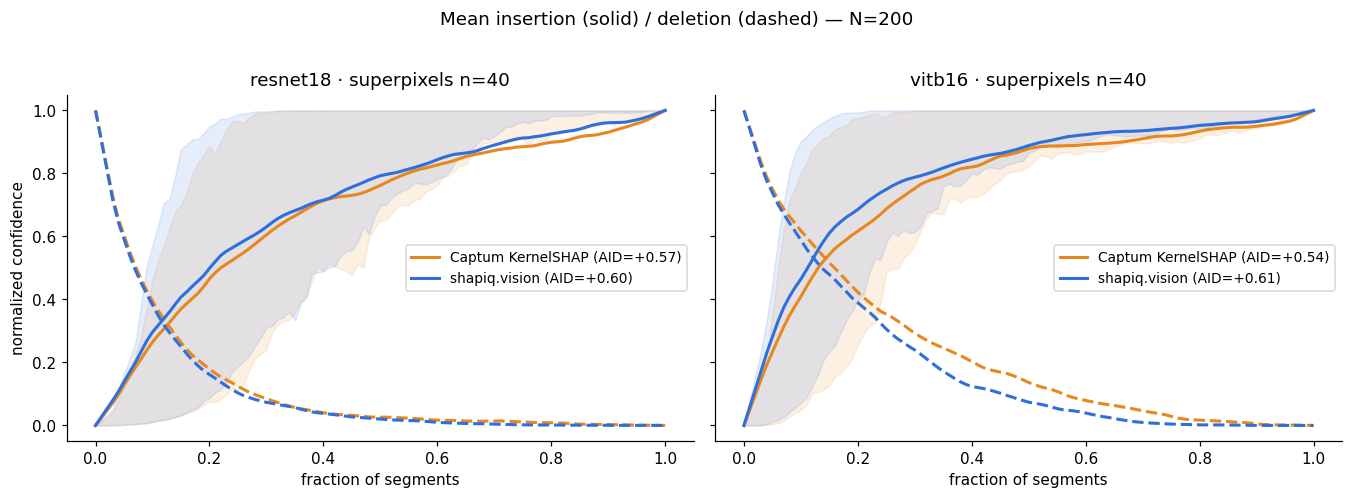

In [11]:
GRID = np.linspace(0, 1, 101)

def interp_curves(curves):
    out = []
    for c in curves:
        c = np.asarray(c, dtype=float)
        out.append(np.interp(GRID, np.linspace(0, 1, len(c)), c))
    return np.vstack(out)

def curves_for(method, model, seg, n_seg, which):
    return [v[which] for (im, mo, me, s, n, ma, r), v in STORE.items()
            if me == method and mo == model and s == seg and n == n_seg]

fig, axes = plt.subplots(1, len(MODELS), figsize=(6.2 * len(MODELS), 4.4), sharey=True)
axes = np.atleast_1d(axes)
for ax, model in zip(axes, MODELS):
    for method in METHODS:
        ins = interp_curves(curves_for(method, model, HERO_SEG, HERO_N, "insertion_curve"))
        dele = interp_curves(curves_for(method, model, HERO_SEG, HERO_N, "deletion_curve"))
        aid = df.query("method == @method and model == @model and "
                       "segmentation == @HERO_SEG and n_segments == @HERO_N").aid.mean()
        ax.plot(GRID, ins.mean(0), color=COLOR[method], lw=2,
                label=f"{LABEL[method]} (AID={aid:+.2f})")
        ax.fill_between(GRID, np.percentile(ins, 25, 0), np.percentile(ins, 75, 0),
                        color=COLOR[method], alpha=0.12)
        ax.plot(GRID, dele.mean(0), color=COLOR[method], lw=2, ls="--")
    ax.set_title(f"{model} · {HERO_SEG} n={HERO_N}")
    ax.set_xlabel("fraction of segments"); ax.legend(fontsize=9)
axes[0].set_ylabel("normalized confidence")
fig.suptitle(f"Mean insertion (solid) / deletion (dashed) — N={df.image.nunique()}", y=1.02)
fig.tight_layout(); fig.savefig("figures/1_headline_curves.png", bbox_inches="tight"); plt.show()

### Plot 2 — per-image AID agreement (hero config)

One dot per image. Dots on the diagonal = the two methods score that image identically.
Best and worst agreement images are annotated.

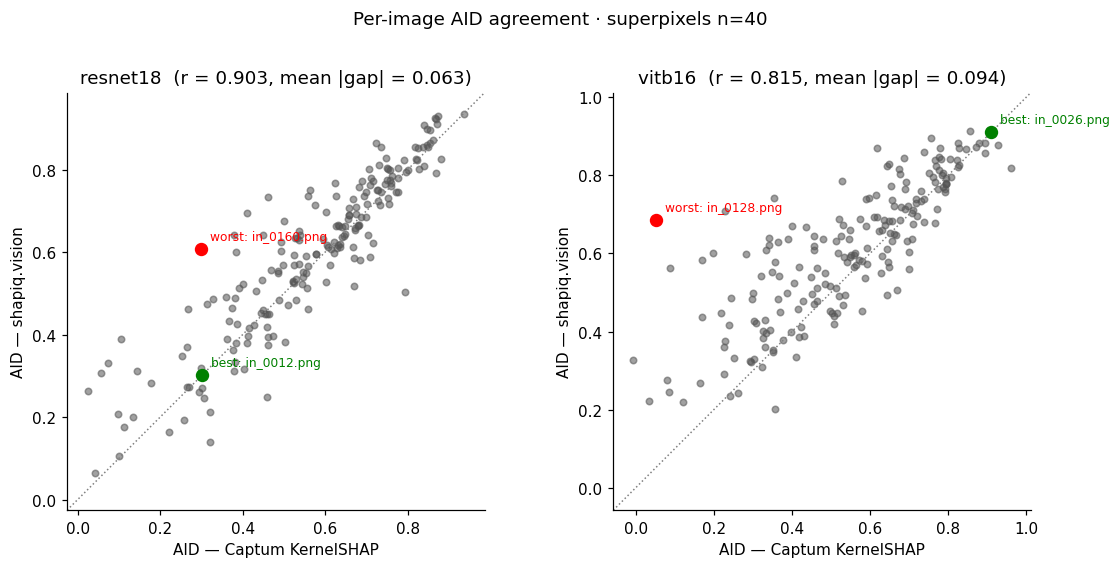

worst-agreement images: {'resnet18': 'in_0160.png', 'vitb16': 'in_0128.png'}


In [12]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(5.4 * len(MODELS), 5))
axes = np.atleast_1d(axes)
worst_by_model = {}
for ax, model in zip(axes, MODELS):
    sub = df.query("model == @model and segmentation == @HERO_SEG and n_segments == @HERO_N")
    piv = sub.pivot_table(index="image", columns="method", values="aid").dropna()
    x, y = piv["kernel_shap"], piv["shapiq_vision"]
    lim = [min(x.min(), y.min()) - 0.05, max(x.max(), y.max()) + 0.05]
    ax.plot(lim, lim, color="grey", lw=1, ls=":")
    ax.scatter(x, y, s=18, alpha=0.55, color="#555")
    gap = (x - y).abs()
    for tag, img, col in [("best", gap.idxmin(), "green"), ("worst", gap.idxmax(), "red")]:
        ax.scatter(x[img], y[img], s=60, color=col, zorder=3)
        ax.annotate(f"{tag}: {img}", (x[img], y[img]), fontsize=8,
                    xytext=(6, 6), textcoords="offset points", color=col)
    worst_by_model[model] = gap.idxmax()
    r = np.corrcoef(x, y)[0, 1]
    ax.set_title(f"{model}  (r = {r:.3f}, mean |gap| = {gap.mean():.3f})")
    ax.set_xlabel("AID — Captum KernelSHAP"); ax.set_ylabel("AID — shapiq.vision")
    ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
fig.suptitle(f"Per-image AID agreement · {HERO_SEG} n={HERO_N}", y=1.02)
fig.tight_layout(); fig.savefig("figures/2_agreement_scatter.png", bbox_inches="tight"); plt.show()
print("worst-agreement images:", worst_by_model)

### Plot 3 — mean AID across the four configurations

Superpixels n=40 outperform grid n=100 for both methods. shapiq.vision shows advantage in both configurations. Error bars = 95% CI over images.

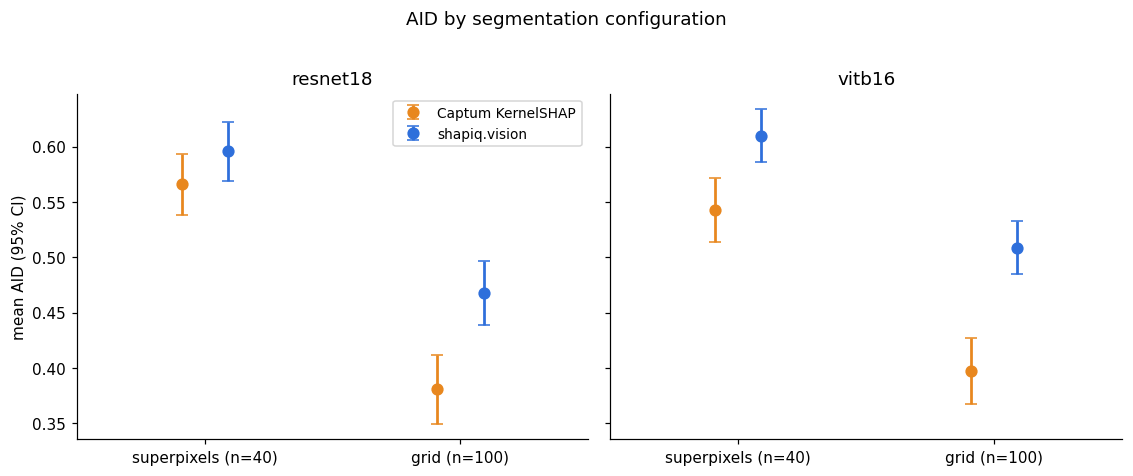

In [13]:
CONFIGS = [("superpixels", 40), ("grid", 100)]
xpos, width = np.arange(len(CONFIGS)), 0.18

fig, axes = plt.subplots(1, len(MODELS), figsize=(5.2 * len(MODELS), 4.2), sharey=True)
axes = np.atleast_1d(axes)
for ax, model in zip(axes, MODELS):
    for j, method in enumerate(METHODS):
        means, cis = [], []
        for seg, n in CONFIGS:
            sub = df.query("model == @model and method == @method and "
                           "segmentation == @seg and n_segments == @n").aid
            means.append(sub.mean()); cis.append(1.96 * sub.sem())
        ax.errorbar(xpos + (j - 0.5) * width, means, yerr=cis,
                    color=COLOR[method], marker="o", ls="none", ms=7,
                    capsize=4, lw=1.8, label=LABEL[method])
    ax.set_xticks(xpos, [f"{seg} (n={n})" for seg, n in CONFIGS])
    ax.set_title(model); ax.set_xlim(-0.5, len(CONFIGS) - 0.5)
axes[0].set_ylabel("mean AID (95% CI)"); axes[0].legend(fontsize=9)
fig.suptitle("AID by segmentation configuration", y=1.02)
fig.tight_layout(); fig.savefig("figures/3_segmentation_sweep.png", bbox_inches="tight"); plt.show()

### Summary table

In [14]:
summary = (df.pivot_table(index=["model", "segmentation", "n_segments"],
                          columns="method", values="aid", aggfunc="mean").round(3))
summary["gap"] = (summary["kernel_shap"] - summary["shapiq_vision"]).round(3)
print(summary)

hero = df.query("segmentation == @HERO_SEG and n_segments == @HERO_N")
piv = hero.pivot_table(index=["model", "image"], columns="method", values="aid").dropna()
close = (abs(piv["kernel_shap"] - piv["shapiq_vision"]) < 0.05).mean()
print(f"\nhero config: {close:.0%} of image×model cells agree within 0.05 AID")

method                            kernel_shap  shapiq_vision    gap
model    segmentation n_segments                                   
resnet18 grid         100               0.381          0.468 -0.087
         superpixels  40                0.566          0.596 -0.030
vitb16   grid         100               0.397          0.509 -0.112
         superpixels  40                0.543          0.610 -0.067

hero config: 50% of image×model cells agree within 0.05 AID
